# Practical Work 3 — Data Visualization: Multidimensional Data

**Datasets:**
- **Wine quality:** [Kaggle — Wine Quality Dataset](https://www.kaggle.com/datasets/yasserh/wine-quality-dataset)
- **Diabetes:** [Kaggle — Diabetes Dataset](https://www.kaggle.com/datasets/akshaydattatraykhare/diabetes-dataset)

**Goal:** Explore univariate, bivariate, multivariate, and high-dimensional visualization techniques.

**Tasks:**
1. **Univariate:** Discrete/categorical attribute in 1-D
2. **Bivariate:** Joint plot for alcohol and quality (wine)
3. **Boxplot & Violin:** Compare distributions of alcohol across quality levels
4. **Multivariate:** Parallel coordinates
5. **3D:** Scatter plot for alcohol, density, pH
6. **Distribution:** Alcohol across different quality levels

**Deliverables:** Summarized report with screenshots of each plot + code (this notebook).  
**Note:** Run the notebook from the `pw3` folder so paths `dataset/` and `charts/` work.

---
## 1. Imports and setup

We use **pandas** for data, **matplotlib** and **seaborn** for plotting, and **plotly** (or mplot3d) for 3D scatter.  
Plots are saved under `pw3/charts/` for the report.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')

CHARTS_DIR = 'charts'
os.makedirs(CHARTS_DIR, exist_ok=True)

def save_fig(name):
    plt.tight_layout()
    plt.savefig(os.path.join(CHARTS_DIR, name), dpi=150, bbox_inches='tight')
    plt.show()

print('Libraries loaded. Charts will be saved to:', os.path.abspath(CHARTS_DIR))

Libraries loaded. Charts will be saved to: /Users/mykytatishkin/PycharmProjects/web-parser/pw3/charts


---
## 2. Load datasets

Place CSV files in `pw3/dataset/`. We load WineQT.csv and diabetes.csv from there.

In [2]:
data_dir = 'dataset'

# --- Wine: try local files first, then load from URL ---
path_qt = os.path.join(data_dir, 'WineQT.csv')
path_red = os.path.join(data_dir, 'winequality-red.csv')
path_white = os.path.join(data_dir, 'winequality-white.csv')
path_sample = os.path.join(data_dir, 'wine_sample.csv')

wine_df = None
if os.path.isfile(path_qt):
    wine_df = pd.read_csv(path_qt)
elif os.path.isfile(path_red):
    wine_red = pd.read_csv(path_red)
    wine_white = pd.read_csv(path_white) if os.path.isfile(path_white) else None
    wine_df = pd.concat([wine_red, wine_white], ignore_index=True) if wine_white is not None else wine_red
elif os.path.isfile(path_sample):
    wine_df = pd.read_csv(path_sample, sep=';')
    print('Wine: loaded from dataset/wine_sample.csv')
else:
    import io
    sample = '''fixed acidity;volatile acidity;citric acid;residual sugar;chlorides;free sulfur dioxide;total sulfur dioxide;density;pH;sulphates;alcohol;quality
7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5
7.8;0.88;0;2.6;0.098;25;67;0.9968;3.2;0.68;9.8;5
7.8;0.76;0.04;2.3;0.092;15;54;0.997;3.26;0.65;9.8;5
11.2;0.28;0.56;1.9;0.075;17;60;0.998;3.16;0.58;9.8;6
7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5
8.2;0.4;0.32;2.1;0.07;15;40;0.996;3.24;0.5;10.2;6
8.9;0.5;0.28;2.2;0.082;21;52;0.9982;3.44;0.66;10.4;6
9.1;0.5;0.26;2.5;0.081;22;54;0.9978;3.4;0.62;10.6;6
'''
    wine_df = pd.read_csv(io.StringIO(sample), sep=';')
    print('Wine: using embedded sample.')

# Normalize column names (spaces -> underscores, lowercase)
if wine_df is not None:
    wine_df.columns = [str(c).strip().lower().replace(' ', '_') for c in wine_df.columns]

# --- Diabetes: try local file first, then URL ---
diabetes_path = os.path.join(data_dir, 'diabetes.csv')
diabetes_df = None
if os.path.isfile(diabetes_path):
    diabetes_df = pd.read_csv(diabetes_path)
else:
    url_diabetes = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.csv'
    diabetes_cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
    try:
        diabetes_df = pd.read_csv(url_diabetes, header=None, names=diabetes_cols)
        print('Diabetes loaded from URL.')
    except Exception as e:
        print('Diabetes URL load failed:', e)

print('Wine shape:', wine_df.shape if wine_df is not None else 'not loaded')
print('Diabetes shape:', diabetes_df.shape if diabetes_df is not None else 'not loaded')
if wine_df is not None:
    display(wine_df.head())

Wine shape: (1143, 13)
Diabetes shape: (768, 9)


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,ph,sulphates,alcohol,quality,id
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,1
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,2
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,3
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,4


---
## 3. Univariate analysis — discrete/categorical in 1-D

**Wine:** Distribution of **quality** (discrete/categorical score).  
**Diabetes:** Distribution of **Outcome** (0/1 class).

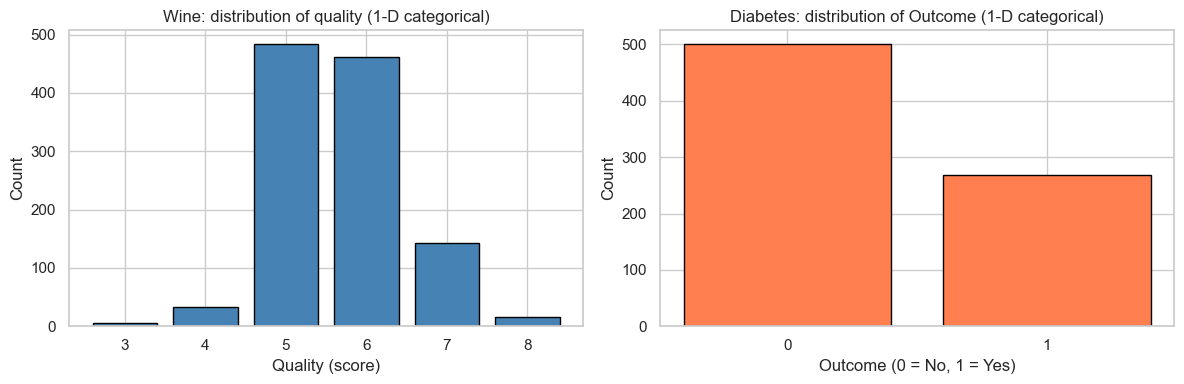

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

if wine_df is not None and 'quality' in wine_df.columns:
    quality_counts = wine_df['quality'].value_counts().sort_index()
    axes[0].bar(quality_counts.index, quality_counts.values, color='steelblue', edgecolor='black')
    axes[0].set_xlabel('Quality (score)')
    axes[0].set_ylabel('Count')
    axes[0].set_title('Wine: distribution of quality (1-D categorical)')

if diabetes_df is not None and 'Outcome' in diabetes_df.columns:
    outcome_counts = diabetes_df['Outcome'].value_counts().sort_index()
    axes[1].bar(outcome_counts.index.astype(str), outcome_counts.values, color='coral', edgecolor='black')
    axes[1].set_xlabel('Outcome (0 = No, 1 = Yes)')
    axes[1].set_ylabel('Count')
    axes[1].set_title('Diabetes: distribution of Outcome (1-D categorical)')

plt.tight_layout()
save_fig('01_univariate_categorical.png')

---
## 4. Bivariate — Joint plot: alcohol vs quality (wine)

Two continuous/numeric attributes: **alcohol** (continuous) and **quality** (ordinal).  
Joint plot shows marginal distributions and scatter (or density) in the middle.

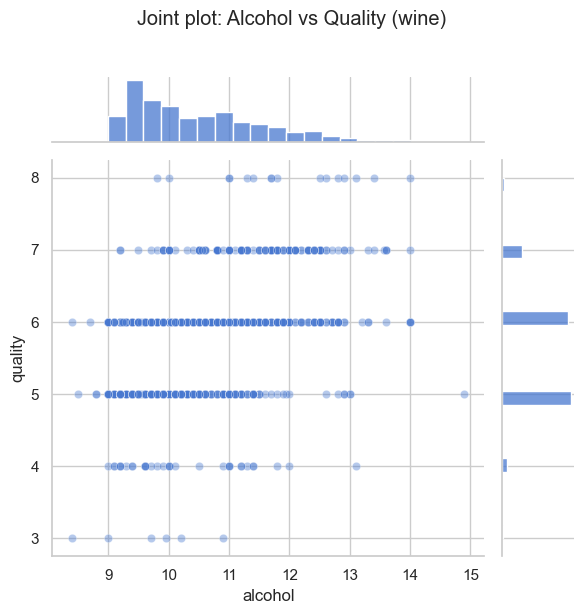

In [4]:
if wine_df is not None and 'alcohol' in wine_df.columns and 'quality' in wine_df.columns:
    g = sns.jointplot(data=wine_df, x='alcohol', y='quality', kind='scatter', alpha=0.4, height=6)
    g.fig.suptitle('Joint plot: Alcohol vs Quality (wine)', y=1.02)
    g.fig.tight_layout()
    g.fig.savefig(os.path.join(CHARTS_DIR, '02_jointplot_alcohol_quality.png'), dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Wine data or columns alcohol/quality not found.')

---
## 5. Boxplot and Violin — alcohol across quality levels

Compare distributions of **alcohol** content across **quality** levels using both boxplot and violin plot.

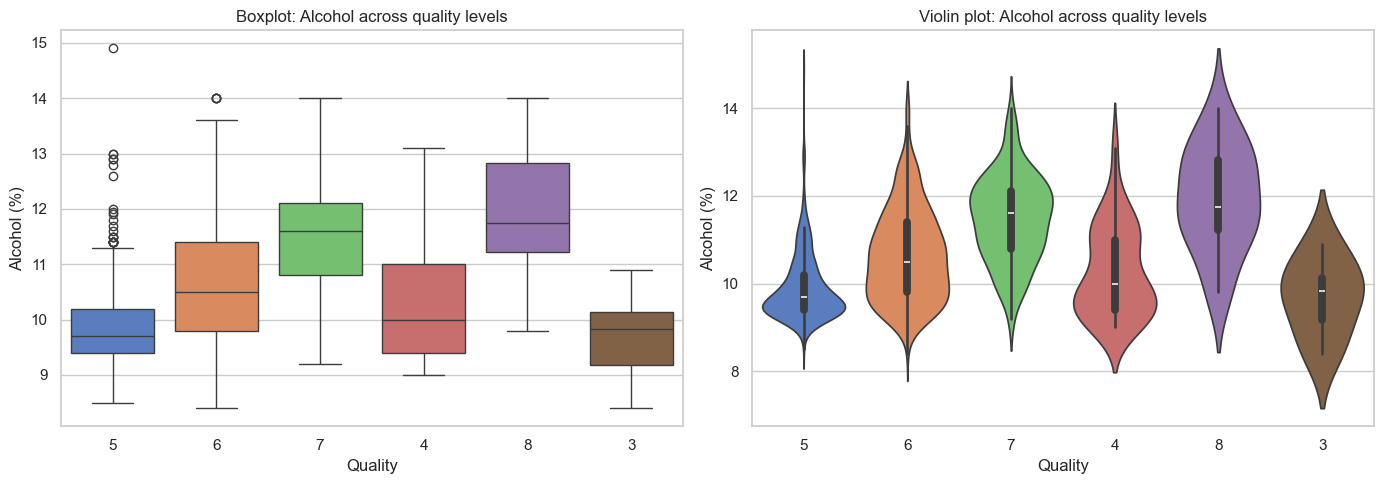

In [5]:
if wine_df is not None and 'alcohol' in wine_df.columns and 'quality' in wine_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    wine_df_plot = wine_df.copy()
    wine_df_plot['quality'] = wine_df_plot['quality'].astype(str)

    sns.boxplot(data=wine_df_plot, x='quality', y='alcohol', ax=axes[0], palette='muted')
    axes[0].set_xlabel('Quality')
    axes[0].set_ylabel('Alcohol (%)')
    axes[0].set_title('Boxplot: Alcohol across quality levels')

    sns.violinplot(data=wine_df_plot, x='quality', y='alcohol', ax=axes[1], palette='muted')
    axes[1].set_xlabel('Quality')
    axes[1].set_ylabel('Alcohol (%)')
    axes[1].set_title('Violin plot: Alcohol across quality levels')

    save_fig('03_boxplot_violin_alcohol_quality.png')
else:
    print('Wine data or columns not found.')

---
## 6. Multivariate — Parallel coordinates

Parallel coordinates plot: each row is a line; each column is an axis.  
We use a subset of numeric columns (wine or diabetes) and optionally color by a categorical (e.g. quality or Outcome).  
To avoid clutter we sample points if the dataset is large.

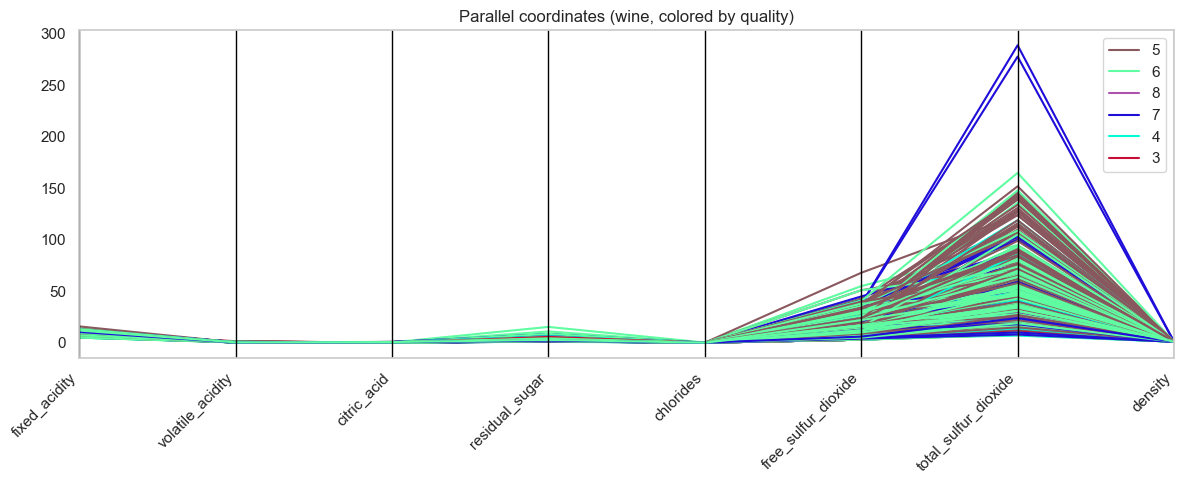

In [6]:
from pandas.plotting import parallel_coordinates

if wine_df is not None and 'quality' in wine_df.columns:
    # Use numeric columns only (exclude Id, quality); limit to 8 axes for readability
    num_cols = [c for c in wine_df.columns if wine_df[c].dtype in ('float64', 'int64')
                and c not in ('quality', 'id')][:8]
    subset_cols = num_cols + ['quality']
    df_par = wine_df[subset_cols].dropna()
    if len(df_par) > 500:
        df_par = df_par.sample(500, random_state=42)
    df_par = df_par.copy()
    df_par['quality'] = df_par['quality'].astype(int).astype(str)
    plt.figure(figsize=(12, 5))
    parallel_coordinates(df_par, 'quality', ax=plt.gca())
    plt.xticks(rotation=45, ha='right')
    plt.title('Parallel coordinates (wine, colored by quality)')
    save_fig('04_parallel_coordinates_wine.png')
else:
    print('Wine data not loaded or no quality column.')

---
## 7. Three dimensions — 3D scatter: alcohol, density, pH

3D scatter plot for **alcohol**, **density**, and **pH** (wine). Points can be colored by **quality**.

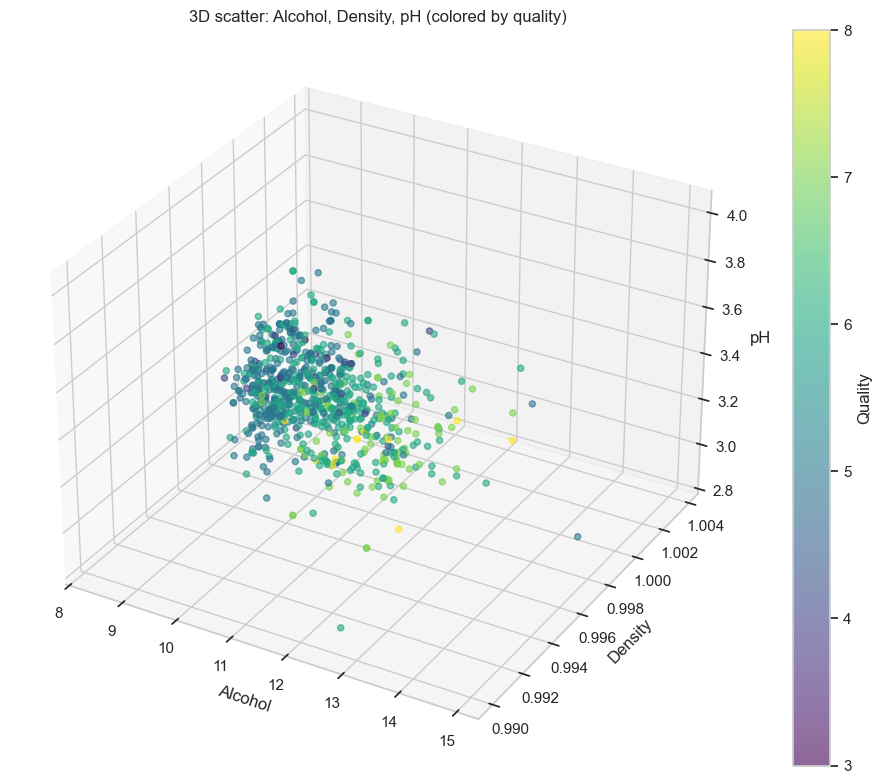

In [7]:
if wine_df is not None and all(c in wine_df.columns for c in ['alcohol', 'density', 'ph']):
    df3 = wine_df[['alcohol', 'density', 'ph', 'quality']].dropna()
    if len(df3) > 800:
        df3 = df3.sample(800, random_state=42)
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(df3['alcohol'], df3['density'], df3['ph'], c=df3['quality'], cmap='viridis', alpha=0.6, s=20)
    ax.set_xlabel('Alcohol')
    ax.set_ylabel('Density')
    ax.set_zlabel('pH')
    plt.colorbar(scatter, label='Quality')
    plt.title('3D scatter: Alcohol, Density, pH (colored by quality)')
    save_fig('05_3d_scatter_alcohol_density_ph.png')
else:
    print('Wine data or columns alcohol/density/pH not found.')

---
## 8. Distribution of alcohol across quality levels

Visualize how **alcohol** is distributed for each **quality** level: overlapping histograms or KDE by quality.

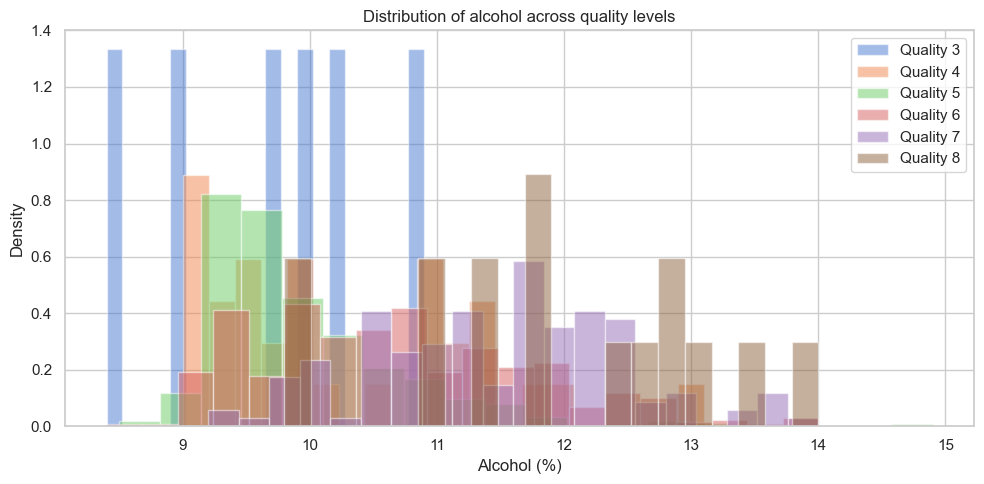

In [8]:
if wine_df is not None and 'alcohol' in wine_df.columns and 'quality' in wine_df.columns:
    plt.figure(figsize=(10, 5))
    for q in sorted(wine_df['quality'].unique()):
        subset = wine_df[wine_df['quality'] == q]['alcohol']
        plt.hist(subset, bins=20, alpha=0.5, label=f'Quality {q}', density=True)
    plt.xlabel('Alcohol (%)')
    plt.ylabel('Density')
    plt.title('Distribution of alcohol across quality levels')
    plt.legend()
    save_fig('06_alcohol_distribution_by_quality.png')
else:
    print('Wine data or columns not found.')